In [16]:
import pandas as pd
import numpy as np
from io import StringIO
import os

# ==========================================================
# FILE LIST
# ==========================================================

files = [
    "Data_Ca_G.csv"
]

# ==========================================================
# LOAD FUNCTION
# ==========================================================

def load_data(filename):
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines

# ==========================================================
# METADATA FUNCTION
# ==========================================================

def extract_metadata(filename):

    parts = filename.replace(".csv", "").split("_")

    subject = parts[1]

    if parts[-1] == "D":
        side = "Right"
    elif parts[-1] == "G":
        side = "Left"
    else:
        side = "Unknown"

    trial = parts[2] if len(parts) == 4 else "1"

    return subject, trial, side

# ==========================================================
# PROCESS FUNCTION
# ==========================================================

def process_file(filename):

    print("\n==================================================")
    print(f"Processing file: {filename}")
    print("==================================================")

    try:
        # ---------- LOAD ----------
        lines = load_data(filename)

        # ---------- FIND BLOCKS ----------
        idx_push = None
        idx_move = None

        for i, line in enumerate(lines):
            if "K-Push" in line:
                idx_push = i
            if "K-Move" in line and idx_move is None:
                idx_move = i

        if idx_push is None or idx_move is None:
            print("❌ Missing K-Push or K-Move")
            return None, None, None, None

        # ---------- SPLIT ----------
        if idx_push < idx_move:
            push_lines = lines[idx_push:idx_move]
            move_lines = lines[idx_move:]
        else:
            push_lines = lines[idx_push:]
            move_lines = lines[idx_move:idx_push]

        # ======================================================
        # K-PUSH
        # ======================================================

        header_idx_push = None
        for i, line in enumerate(push_lines):
            if "temps" in line.lower():
                header_idx_push = i
                break

        if header_idx_push is None:
            print(f"❌ No K-Push header in {filename}")
            return None, None, None, None

        push_str = "".join(push_lines[header_idx_push:])

        df_push = pd.read_csv(
            StringIO(push_str),
            sep=r"\t|,",
            engine="python",
            on_bad_lines="skip"
        )

        df_push = df_push.dropna(axis=1, how='all')

        df_push = df_push.rename(columns={
            "temps (seconde)": "time",
            "CHANNEL_1": "force"
        })

        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

        # ======================================================
        # BASELINE EXTRACTION
        # ======================================================

        baseline = {"wrist": [], "shoulder": []}

        for line in move_lines:
            if "Quaternion de base" in line:

                parts = line.strip().split("\t")
                if len(parts) < 5:
                    parts = line.strip().split(",")

                sensor_name = parts[0]

                values = []
                for x in parts[1:]:
                    try:
                        values.append(float(x))
                    except:
                        continue

                values = values[:4]

                if "S121577" in sensor_name:
                    baseline["wrist"] = values
                elif "S121578" in sensor_name:
                    baseline["shoulder"] = values

        # ======================================================
        # K-MOVE
        # ======================================================

        header_idx_move = None
        for i, line in enumerate(move_lines):
            if "temps" in line.lower():
                header_idx_move = i
                break

        if header_idx_move is None:
            print(f"❌ No K-Move header in {filename}")
            return None, None, None, None

        move_data_lines = move_lines[header_idx_move + 1:]

        split_rows = []
        for line in move_data_lines:
            row = line.strip().split("\t")
            if len(row) < 2:
                row = line.strip().split(",")
            split_rows.append(row)

        df_move = pd.DataFrame(split_rows)

        df_move = df_move.dropna(axis=1, how='all')
        df_move = df_move.apply(pd.to_numeric, errors='coerce')
        df_move = df_move.ffill().bfill()

        # ======================================================
        # SENSOR EXTRACTION
        # ======================================================

        if df_move.shape[1] < 10:
            print(f"❌ Not enough columns in {filename}")
            return None, None, None, None

        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]

        df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]

        # ======================================================
        # METADATA
        # ======================================================

        subject, trial, side = extract_metadata(filename)

        # ======================================================
        # FINAL CHECK (CORRECTLY INDENTED ✅)
        # ======================================================

        print(f"\n===== FILE: {filename} =====")
        print("K-Push shape:", df_push.shape)
        print("Wrist shape:", df_wrist.shape)
        print("Shoulder shape:", df_shoulder.shape)
        print("Baseline wrist:", baseline["wrist"])
        print("Baseline shoulder:", baseline["shoulder"])
        print(f"Metadata → Subject: {subject} | Trial: {trial} | Side: {side}")

        print(f"\n✅ END PROCESSING: {filename}")

        return df_push, df_wrist, df_shoulder, baseline

    except Exception as e:
        print(f"❌ Error in {filename}: {e}")
        return None, None, None, None

# ==========================================================
# MAIN LOOP
# ==========================================================

results = {}

for i, file in enumerate(files):

    print(f"\n📂 File {i+1}/{len(files)}: {file}")
    print(f"➡️ START: {file}")

    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    print(f"⬅️ END: {file}")

    if df_wrist is None:
        print(f"⚠️ Skipped file: {file}")
        continue

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }

print("\n🎯 ALL FILES PROCESSED")


📂 File 1/1: Data_Ca_G.csv
➡️ START: Data_Ca_G.csv

Processing file: Data_Ca_G.csv

===== FILE: Data_Ca_G.csv =====
K-Push shape: (46780, 2)
Wrist shape: (11686, 5)
Shoulder shape: (11686, 5)
Baseline wrist: [0.028, 0.796, 0.585, 0.152]
Baseline shoulder: [-0.218, 0.519, -0.743, 0.362]
Metadata → Subject: Ca | Trial: 1 | Side: Left

✅ END PROCESSING: Data_Ca_G.csv
⬅️ END: Data_Ca_G.csv

🎯 ALL FILES PROCESSED


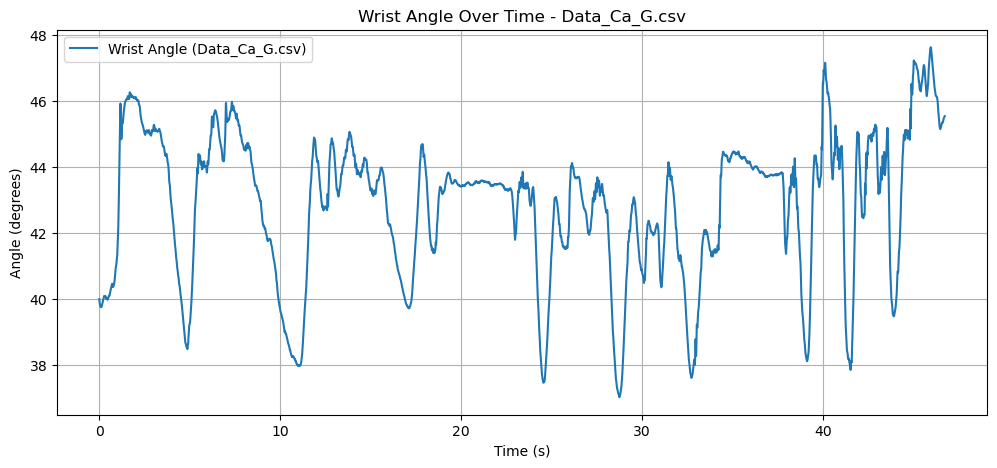

===== FILE: Data_Ca_G.csv =====
Min angle: 37.0352932077605
Max angle: 47.620752904859444


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful elbow/wrist angle.
    """
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: NORMALIZATION ----------
    angle_zeroed = angle_deg - angle_deg[0]
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles

# ==========================================================
# MULTI-FILE PROCESSING (6 FILES)
# ==========================================================

files_to_process = [
   
    "Data_Ca_G.csv"
]

# Baselines (exemple, à ajuster manuellement si besoin)
baseline_angles = {
  
    "Data_Ca_G.csv": 40
}

angles_results = {}

for file in files_to_process:

    # Récupérer les données wrist de process_file
    df_wrist = results[file]["wrist"]

    manual_baseline = baseline_angles[file]

    # Conversion quaternion -> angle anatomique
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

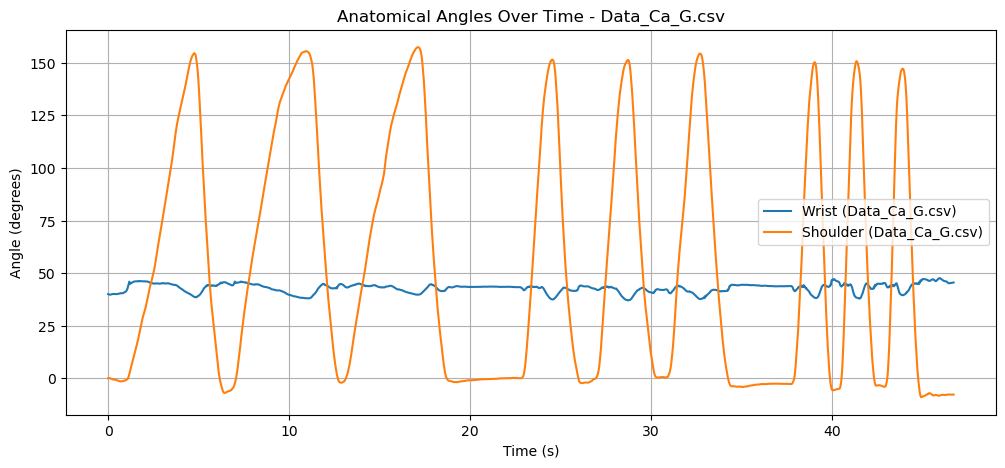

===== FILE: Data_Ca_G.csv =====
Wrist → min: 37.0352932077605 max: 47.620752904859444
Shoulder → min: -9.01336745805581 max: 157.38180645544287


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful angle.
    Works for wrist or shoulder.
    """
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: NORMALIZATION ----------
    angle_zeroed = angle_deg - angle_deg[0]
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles

# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files_to_process = [
  
    "Data_Ca_G.csv"
]

# Baselines manuelles (à ajuster si besoin)
baseline_angles = {
 
    "Data_Ca_G.csv": {"wrist":40, "shoulder":0}
}

# Stocker les résultats
angles_results = {}

for file in files_to_process:

    # Récupérer les données wrist et shoulder de process_file
    df_wrist = results[file]["wrist"]
    df_shoulder = results[file]["shoulder"]

    manual_baseline_wrist = baseline_angles[file]["wrist"]
    manual_baseline_shoulder = baseline_angles[file]["shoulder"]

    # Conversion quaternion → angle anatomique
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline_wrist)
    df_shoulder_angles = quaternion_to_angle_x_corrected(df_shoulder, manual_baseline_shoulder)

    angles_results[file] = {
        "wrist": df_wrist_angles,
        "shoulder": df_shoulder_angles
    }

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist ({file})")
    plt.plot(df_shoulder_angles["time"], df_shoulder_angles["angle"], label=f"Shoulder ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Anatomical Angles Over Time - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Wrist → min:", df_wrist_angles["angle"].min(), "max:", df_wrist_angles["angle"].max())
    print("Shoulder → min:", df_shoulder_angles["angle"].min(), "max:", df_shoulder_angles["angle"].max())